In [1]:
#Import Required Packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import the CSV data as Pandas DataFrame
df = pd.read_csv('data/StudentsPerformance.csv')

In [3]:
# Show Top 5 Records
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
# Show Bottom 5 records
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [5]:
# Shape of the dataset
df.shape

(1000, 8)

In [6]:
# Check Missing Values
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
# Check Duplicates
df.duplicated().sum()

# df.duplicated(subset=None, keep='first') check duplicates based on specific column(s) keep = 'first', 'last', pr 'False'
# df.drop_duplicates(subset=None, keep='first', inplace=False) subset - Remove duplicates based on specific column(s) keep - which duplicate to keep, inplace - True modifies original DataFrame

np.int64(0)

In [8]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
# Checking the number of unique values of each column
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [10]:
# Check statistics of dataset
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
# Exploring categorical data
print("Categories in 'gender' variable:          ", end=" ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:   ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable:", end=" ")
print(df["parental level of education"].unique())

print("Categories in 'lunch' variable:      ", end=" ")
print(df["lunch"].unique())

print("Categories in 'test preparation coure' variable:      ", end=" ")
print(df["test preparation course"].unique())

Categories in 'gender' variable:           ['female' 'male']
Categories in 'race_ethnicity' variable:    ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:       ['standard' 'free/reduced']
Categories in 'test preparation coure' variable:       ['none' 'completed']


In [12]:
# define numerical & categorical columns
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print(f"We have {len(numerical_features)} numerical features: {numerical_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 3 numerical features: ['math score', 'reading score', 'writing score']
We have 5 categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [13]:
# Adding columns for "Total Score" and "Average"
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total_score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [14]:
# Trying to get students with full marks
reading_full = df[df['reading score'] == 100]['reading score'].count()
writing_full = df[df['writing score'] == 100]['writing score'].count()
math_full = df[df['math score'] == 100]['math score'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [15]:
# Trying to get students with less than 20 marks
reading_less_20 = df[df['reading score'] <= 20]['reading score'].count()
writing_less_20 = df[df['writing score'] <= 20]['writing score'].count()
math_less_20 = df[df['math score'] <= 20]['math score'].count()

print("Number of students with less than 20 marks in Maths: {}.".format(math_less_20))
print("Number of students with less than 20 marks in Reading: {}.".format(reading_less_20))
print("Number of students with less than 20 marks in Writing: {}.".format(writing_less_20))

Number of students with less than 20 marks in Maths: 4.
Number of students with less than 20 marks in Reading: 1.
Number of students with less than 20 marks in Writing: 3.


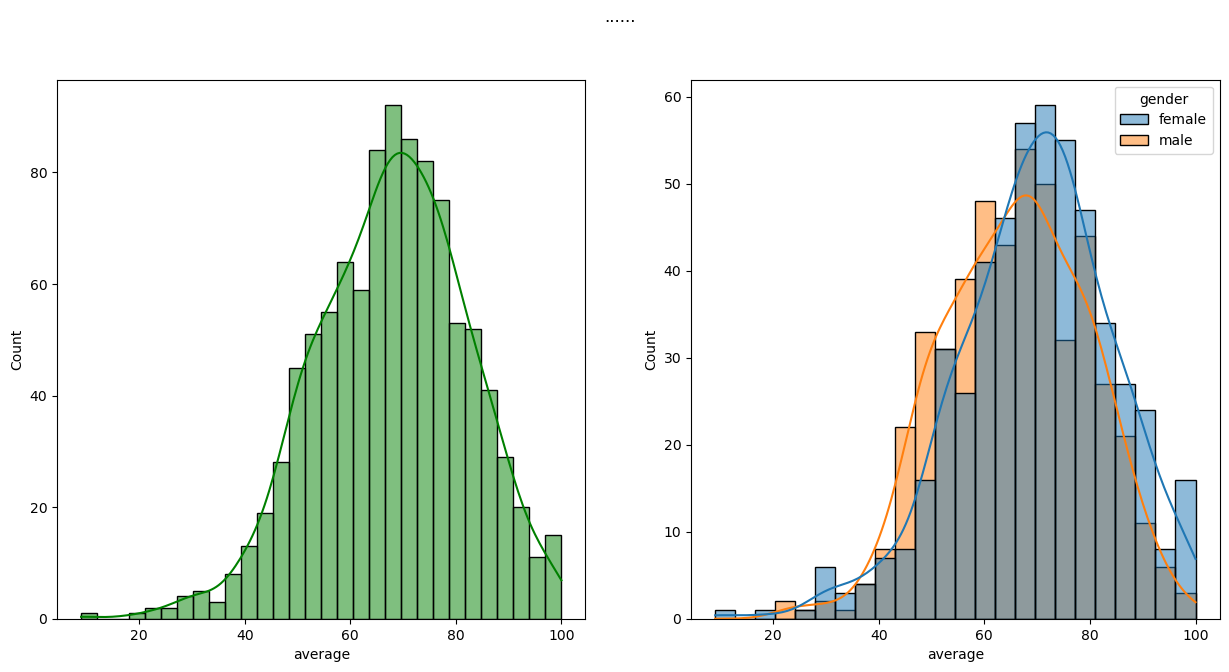

In [16]:
# Exploring Data (Visualization)
# Histogram & KDE
# Visualize average score distribution to make some conclusion

fig, axs = plt.subplots(1, 2, figsize=(15, 7)) # plt.subplots(nrows=1,ncols=1,figsize=None,sharex=False,sharey=False,squeeze=True,i=None,..)
plt.subplot(121) # plt.subplot(nrows, ncols, index)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g') # sns.histplot(data=None, x=None, y=None, hue=None,bins='auto',color=None,stat='count',multiple='layer',ax=None)
plt.subplot(122)
sns.histplot(data=df,x='average', kde=True, hue='gender')
fig.suptitle("......")
plt.show()

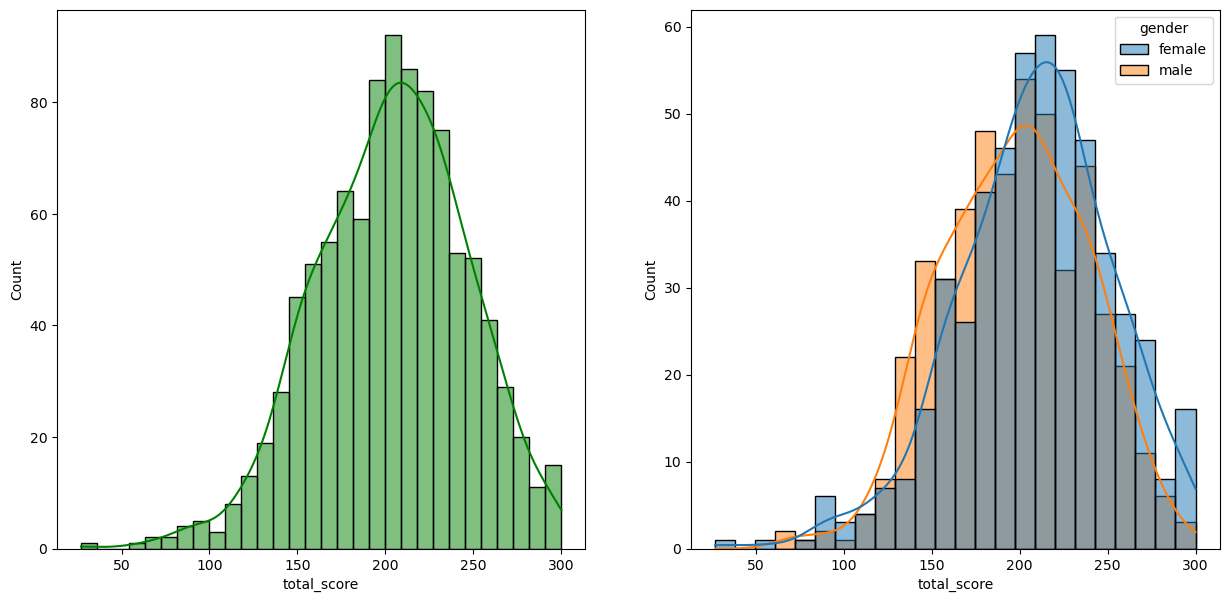

In [17]:
fig, axs = plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='total_score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='total_score', kde=True, hue='gender')
plt.show()

- Female students seems to perform better than male students

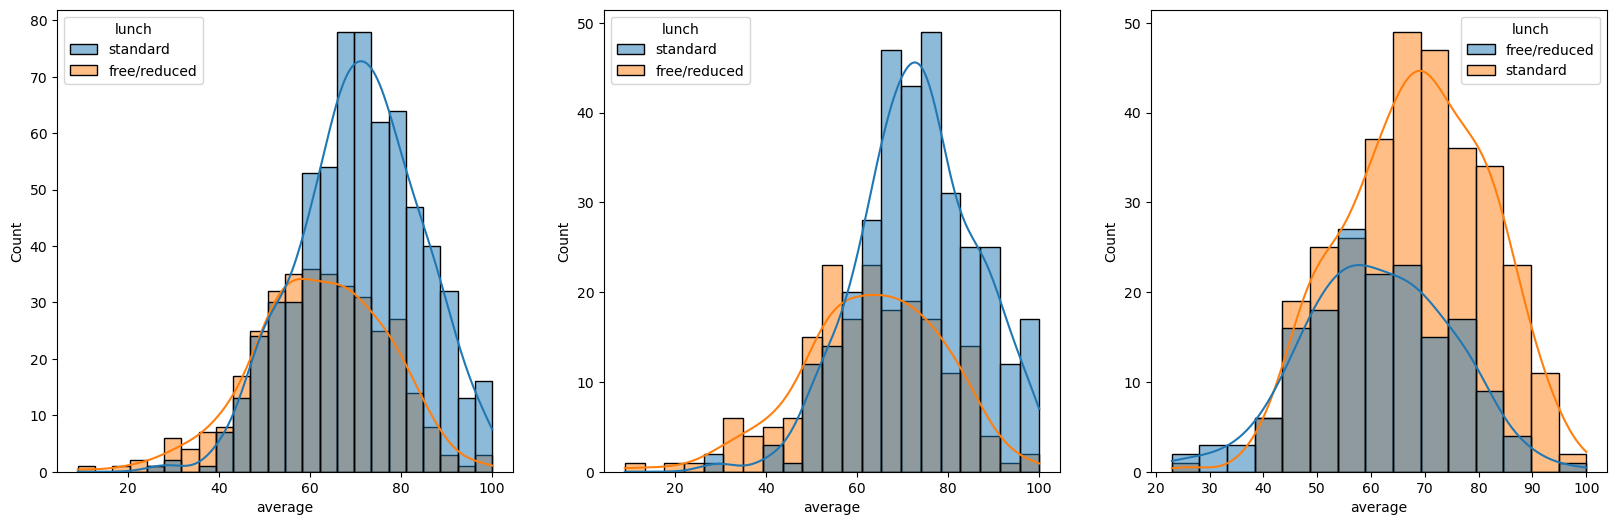

In [18]:
plt.subplots(1,3,figsize=(20,6))
plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='lunch')
plt.subplot(132)
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='lunch')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='lunch')
plt.show()

- Standard lunch helps perform well in exams whether they are male or female

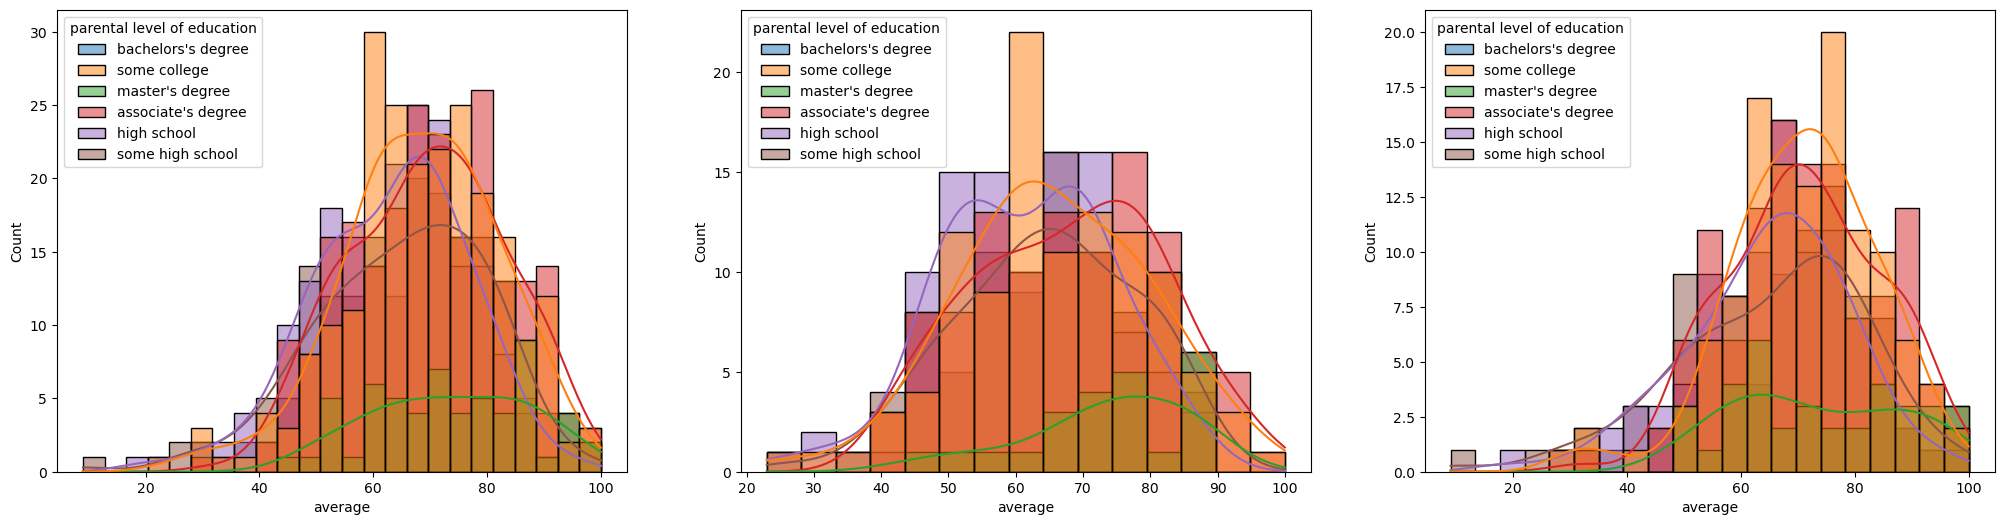

In [19]:
hue_order=[
    "bachelors's degree",
    "some college",
    "master's degree",
    "associate's degree",
    "high school",
    "some high school"
]
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df, x='average',kde=True, hue='parental level of education', hue_order=hue_order)
plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental level of education', hue_order=hue_order)
plt.subplot(133)
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='parental level of education', hue_order=hue_order)
plt.show()

- In general parent's education don't help students perform well in exam.

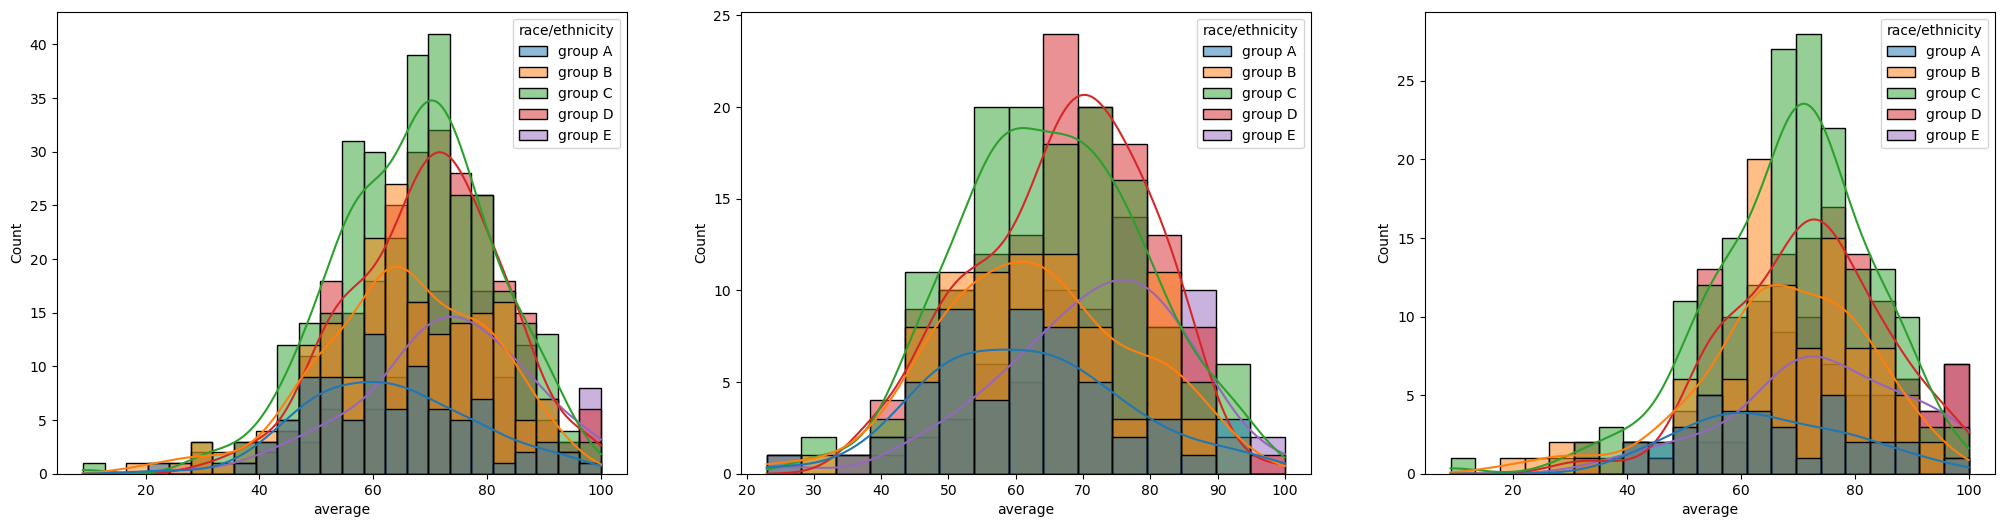

In [20]:
hue_order=[
    "group A",
    "group B",
    "group C",
    "group D",
    "group E"
]
plt.subplots(1,3, figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='race/ethnicity',hue_order=hue_order)
plt.subplot(132)
sns.histplot(data=df[df['gender']=='male'], x='average', kde=True, hue='race/ethnicity', hue_order=hue_order)
plt.subplot(133)
sns.histplot(data=df[df['gender']=='female'], x='average', kde=True, hue='race/ethnicity', hue_order=hue_order)
plt.show()

- Students of group A and group B tends to perform weakly in exam irrespective of their gender.

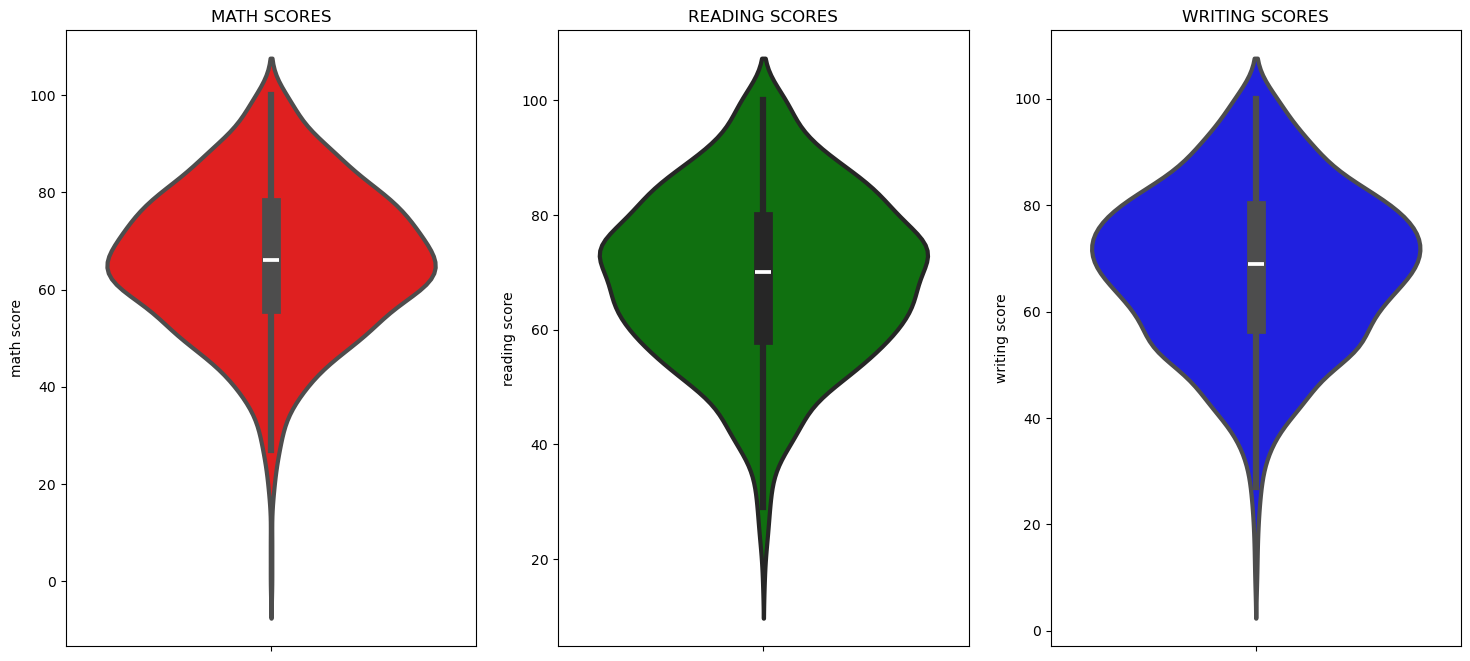

In [21]:
# Maximum score of students in all three subjects
plt.figure(figsize=(18,8)) # (figsize(width, height))
plt.subplot(131)
plt.title('MATH SCORES') # plt.title(label, fontsize=None,color=None,loc='center',...)
sns.violinplot(data=df,y='math score',color='red', linewidth=3) # sns.violinplot(data=None, x=None, y=None, hue=None,color=None,linewidth=None,inner='box',split=False,ax=None,...)
plt.subplot(132)
plt.title("READING SCORES")
sns.violinplot(data=df, y='reading score', color='green', linewidth=3)
plt.subplot(133)
plt.title('WRITING SCORES')
sns.violinplot(data=df,y='writing score', color='blue', linewidth=3)
plt.show()

- From the above three violin plots its cleary visible that most of the students score in between 60-80

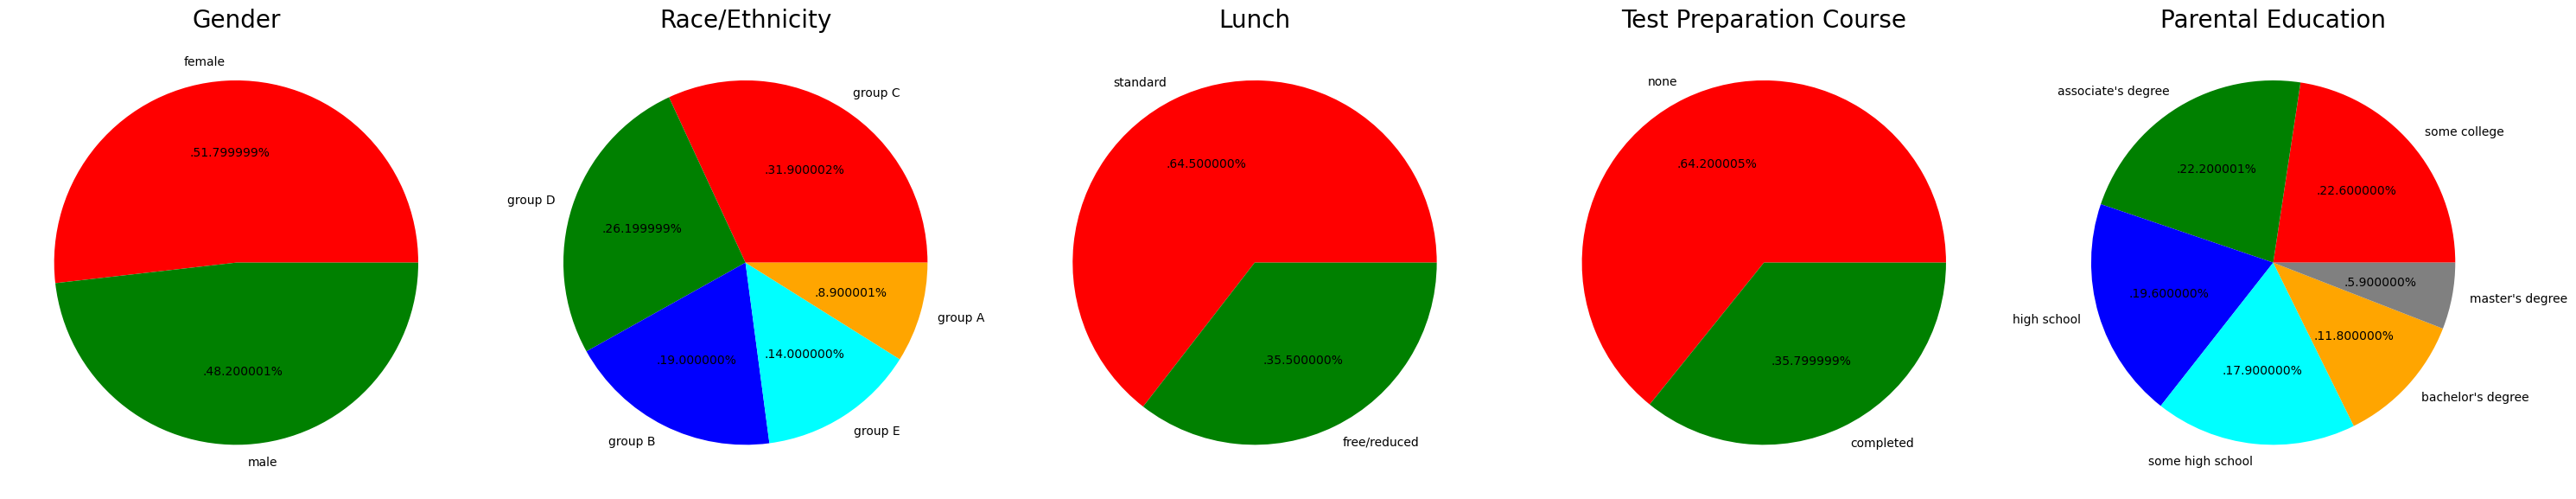

In [22]:
# Multivariate analysis using pieplot

plt.rcParams['figure.figsize'] = (30,12) # plt.rcParams['parameter_name'] = value, When you want to change the default size for all future figures.

plt.subplot(151)
size = df['gender'].value_counts()
color= ['red', 'green']

plt.pie(size, colors=color, labels=size.index, autopct='.%2f%%') # plt.pie(x,labels=None,color=None,autopct=None,explode=None,startangle=0,shadow=False,radius=1,counterclock=True,...)
plt.title('Gender', fontsize = 20)
plt.axis('off')

plt.subplot(152)
size = df['race/ethnicity'].value_counts()
color = ['red', 'green', 'blue', 'cyan', 'orange']

plt.pie(size, labels=size.index, colors=color, autopct='.%2f%%')
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')

plt.subplot(153)
size=df['lunch'].value_counts()
color = ['red', 'green']

plt.pie(size, labels=size.index, colors=color, autopct='.%2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

plt.subplot(154)
size = df['test preparation course'].value_counts()
color = ['red', 'green']

plt.pie(size, colors=color, labels=size.index, autopct='.%2f%%')
plt.title('Test Preparation Course', fontsize=20)
plt.axis('off')

plt.subplot(155)
size = df['parental level of education'].value_counts()
color = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']

plt.pie(size, labels=size.index, colors=color, autopct='.%2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()

plt.show()

- Number of Male and Female students is almost equal
- Number of students are greatest in group C
- Number of students who have Standard lunch are greater
- Number of students who have not enorlled in any test prepartion course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

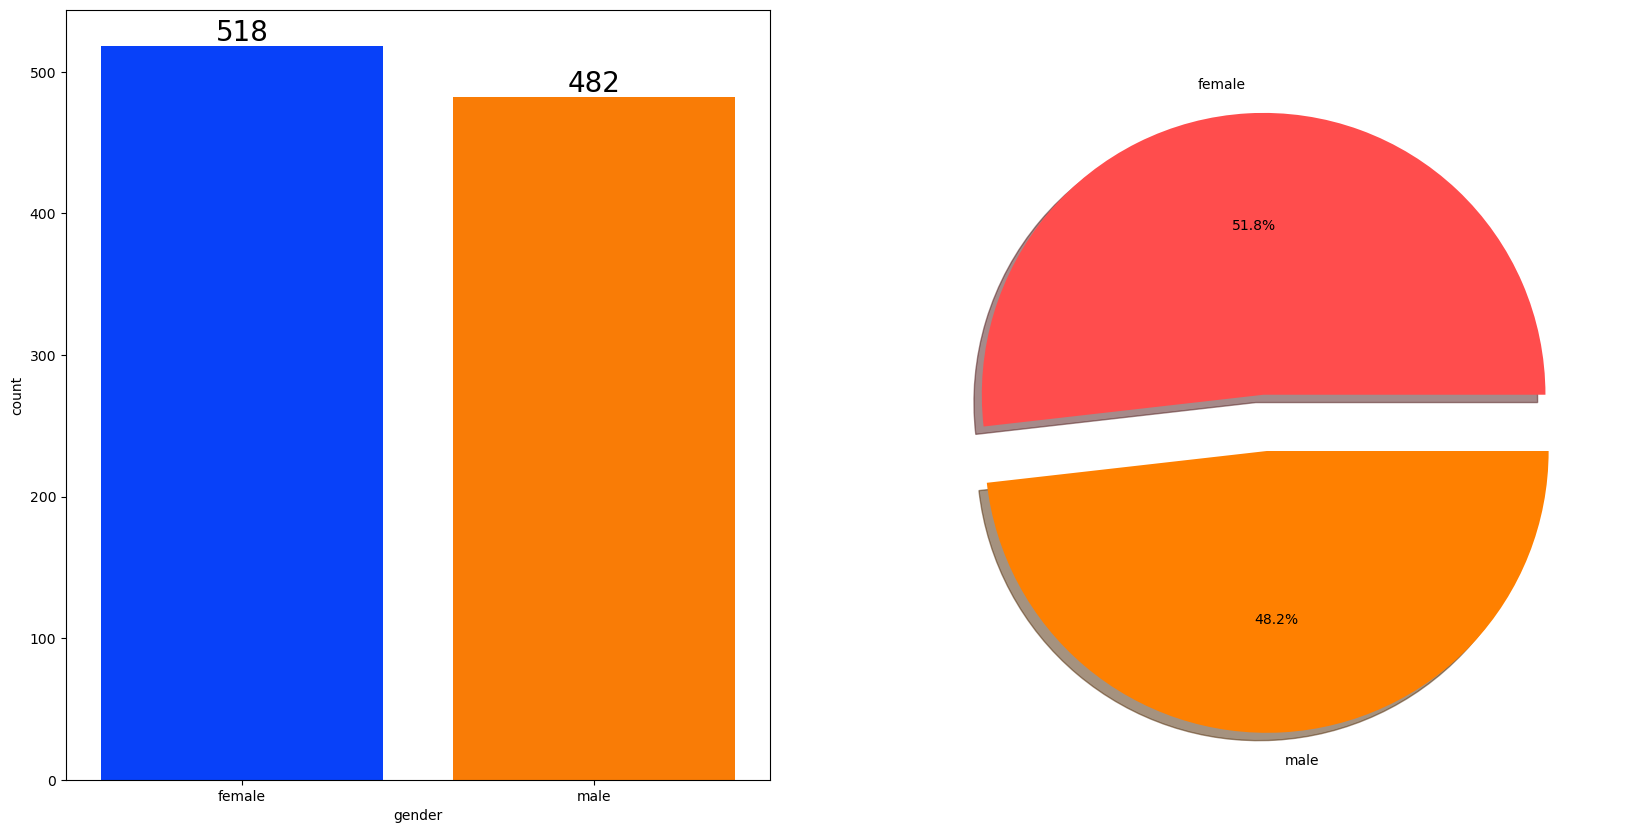

In [23]:
# Univariate Analysis (How is distribution of Gender?
f,ax=plt.subplots(1,2, figsize=(20,10))
sns.countplot(x=df['gender'], data=df, palette='bright',ax=ax[0],saturation=0.95) # sns.countplot(data=None,x=None,y=None,hue=None,order=None,hue_order=None,palette=None,color=None,saturation=0.75,ax=None,...)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black',size=20) # ax.bar_label(container,labels=None,fmt='%g',padding=0,color=None,size=None,...)
    
counts = df['gender'].value_counts()
plt.pie(counts, labels=counts.index,explode=[0,0.2],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d', '#ff8000'])
plt.show()

- Gender has balanced data with female students are 518 and male students are 482.

In [24]:
# BIVARIATE ANALYSIS (does gender has any impact on student's performance.)
gender_group = df.groupby('gender').mean(numeric_only=True) # df.groupby(by, axis=0,as_index=True,sort=True,dropna=True,...)
gender_group

,math score,reading score,writing score,total_score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


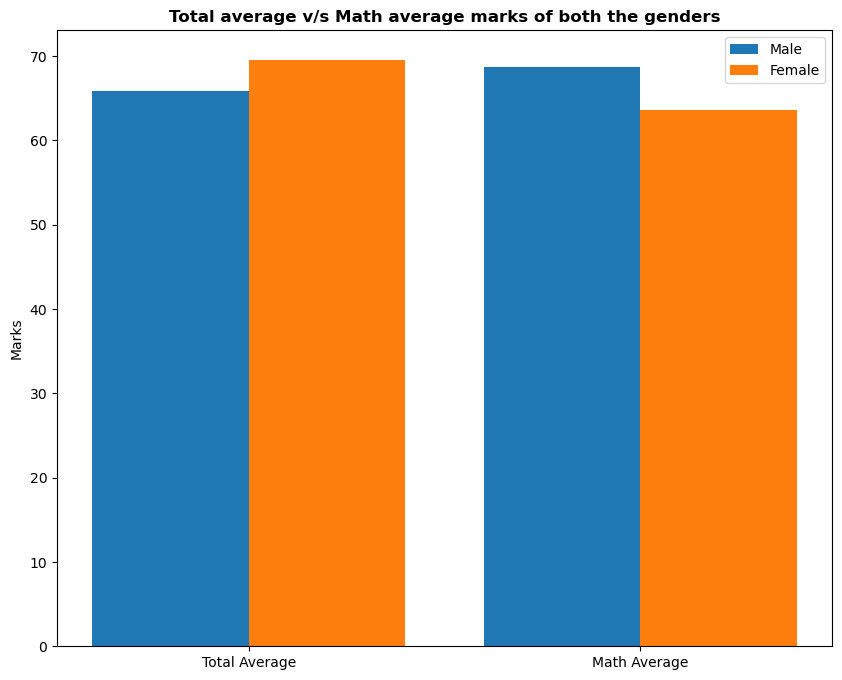

In [25]:
plt.figure(figsize=(10,8)) # when you need a single figure and no subplots

X = ["Total Average", "Math Average"]

female_scores = [gender_group['average'][0],gender_group['math score'][0]]
male_scores = [gender_group['average'][1], gender_group['math score'][1]]

X_axis=np.arange(len(X))

plt.bar(X_axis-0.2, male_scores,0.4, label='Male') # plt.bar(x, height, width, label=None,color=None,)
plt.bar(X_axis+0.2, female_scores,0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel('Marks')
plt.title('Total average v/s Math average marks of both the genders', fontweight='bold')
plt.legend()
plt.show()

- On an average females have a better overall score than men.
- Whereas males have score higher in Maths.

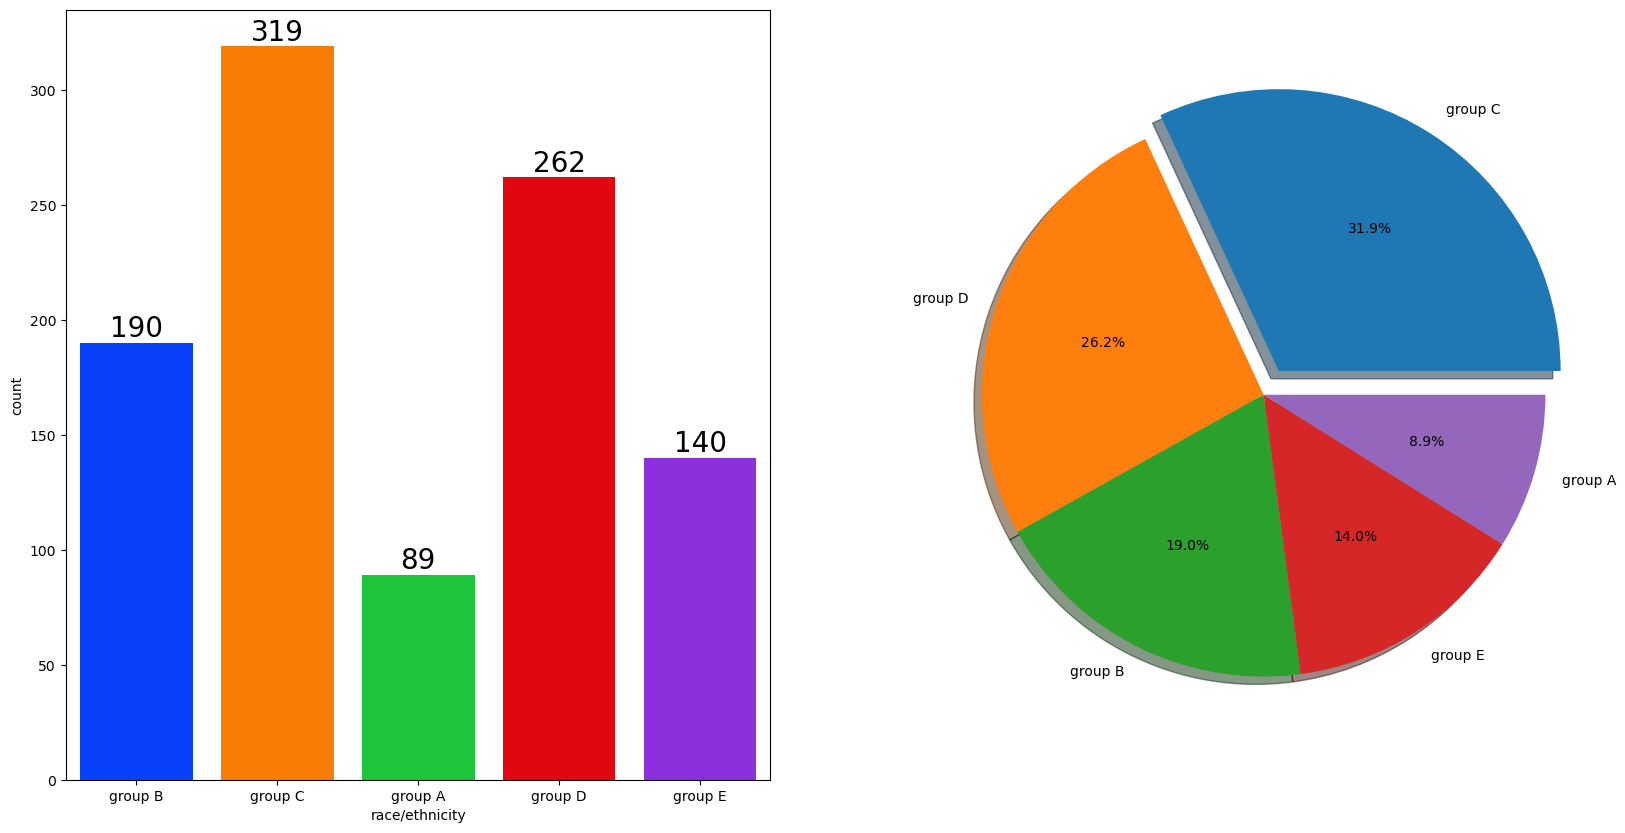

In [26]:
# UNIVARIATE ANALYSIS (How is Group wise distribution?)
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'], data=df, palette= 'bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
counts = df['race/ethnicity'].value_counts()
plt.pie(counts,labels=counts.index,explode=[0.1,0,0,0,0],autopct="%1.1f%%", shadow=True)
plt.show()

- most of the students belonging from groupC / groupD.
- Lowest number of student belonging to groupA.

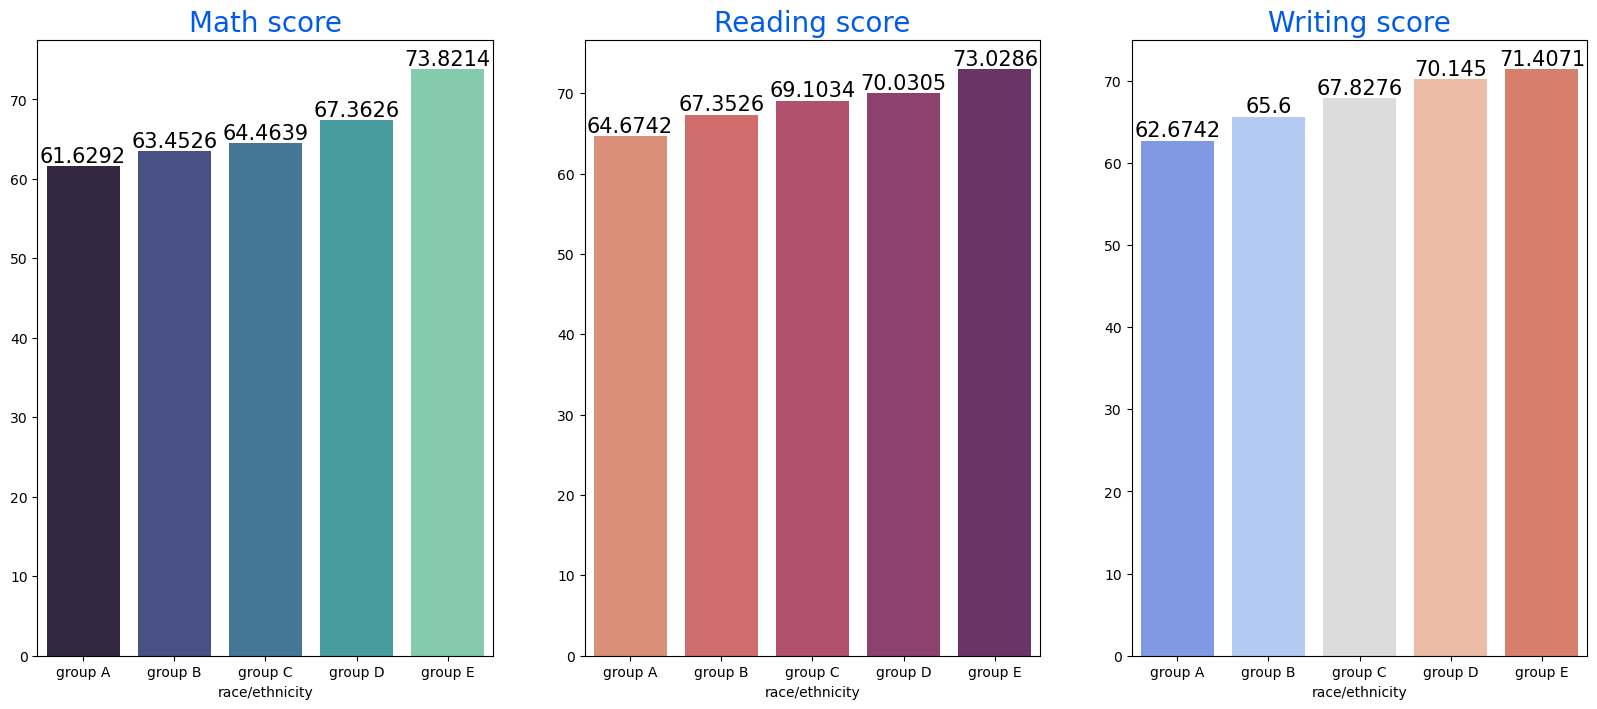

In [27]:
# BIVARIATE ANALYSIS (Is race/ethnicity has any impact on student's performance?)

group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8)) # when you need one or more subplots
sns.barplot(x=group_data2['math score'].mean().index,y=group_data2['math score'].mean().values,palette='mako',ax=ax[0]) # sns.barplot(data=None,x=None,y=None,hue=None,palette=None,color=None,estimator='mean',errorbar=('ci',95), ax=None,...)
ax[0].set_title('Math score', color='#005ce6', size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=group_data2['reading score'].mean().index, y=group_data2['reading score'].mean().values,palette='flare',ax=ax[1])
ax[1].set_title('Reading score', color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=group_data2['writing score'].mean().index,y=group_data2['writing score'].mean().values,palette='coolwarm',ax=ax[2])
ax[2].set_title('Writing score', color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.

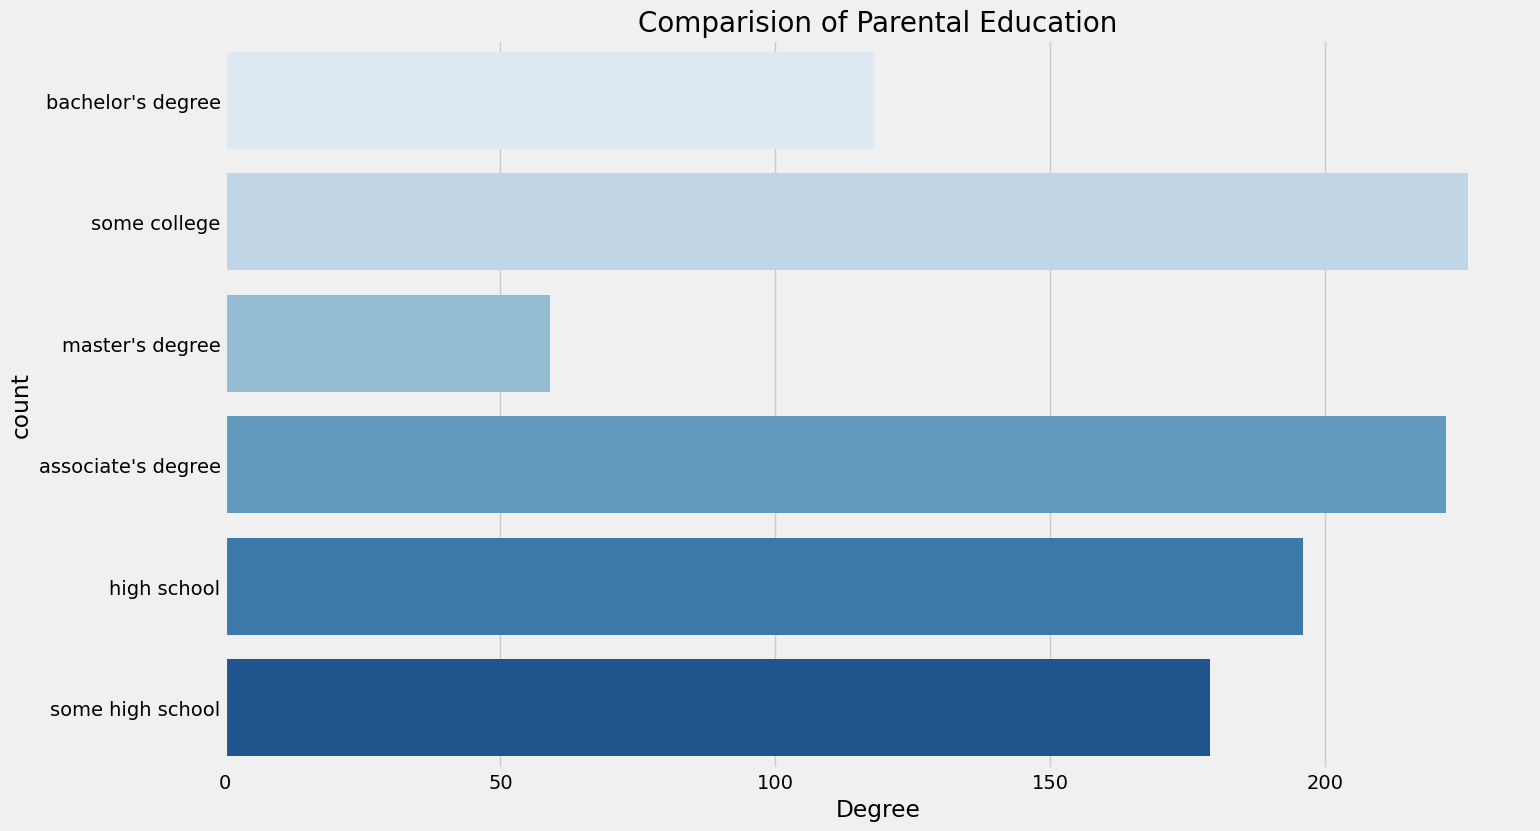

In [28]:
# UNIVARIATE ANALYSIS (What is educational background of student's parent?)
plt.rcParams['figure.figsize'] = (15,9) 
plt.style.use('fivethirtyeight') # plt.style.use(style_name)
sns.countplot(df['parental level of education'], palette='Blues')
plt.title('Comparision of Parental Education', fontweight=30,fontsize=20)
plt.xlabel('Degree') # plt.xlabel(xlabel,fontsize=None,color=None,...)
plt.ylabel('count') # plt.ylabel(ylabel,fontsize=None,color=None,...)
plt.show()

- Largest number of parents are from some college followed by associate's degree.

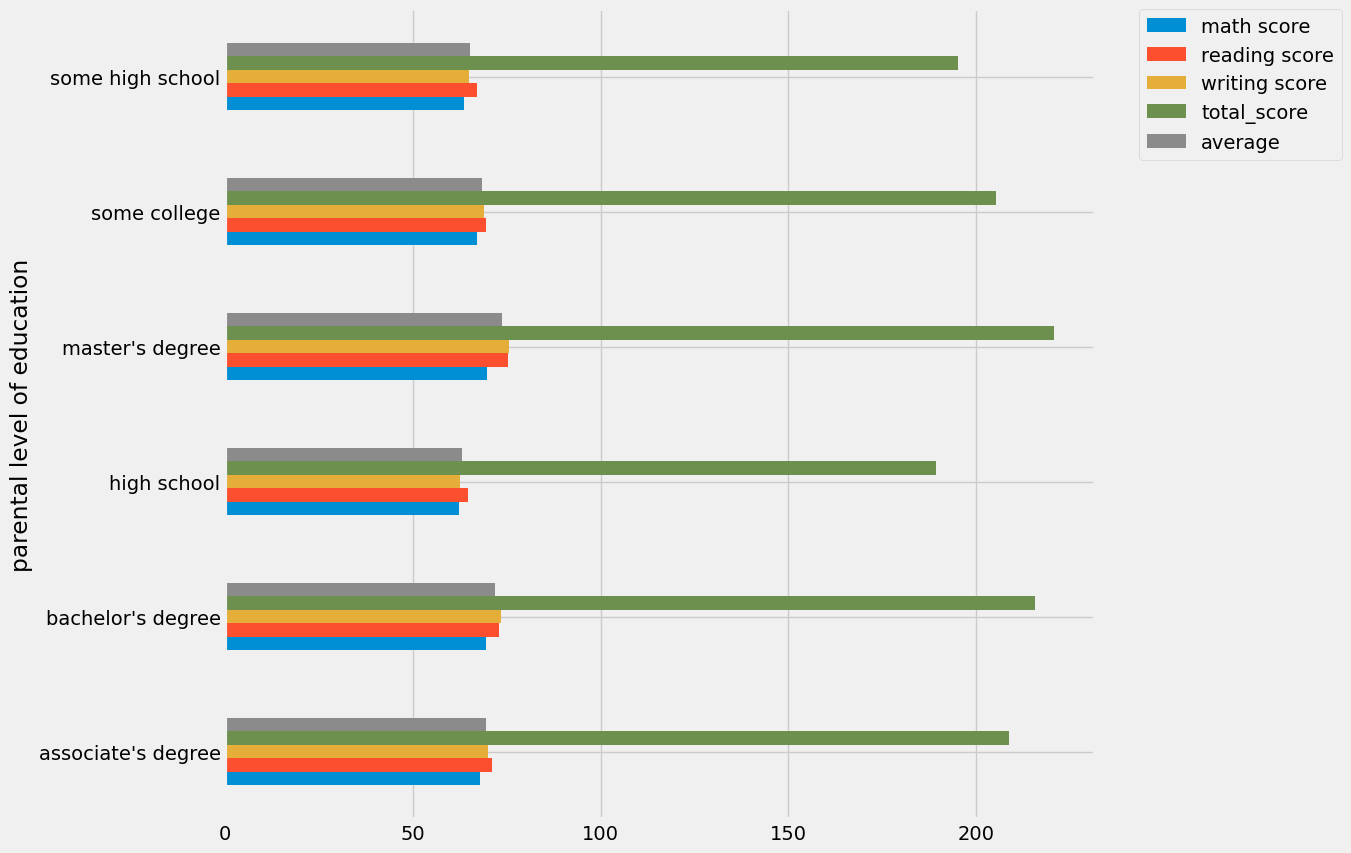

In [29]:
# BIVARIATE ANALYSIS(Is parental education has any impact on student's performance?)

df.groupby('parental level of education').mean(numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05,1), loc=2,borderaxespad=0.)
plt.show()

- The student whose parents possess master and bachelor degree level education are higher than others.

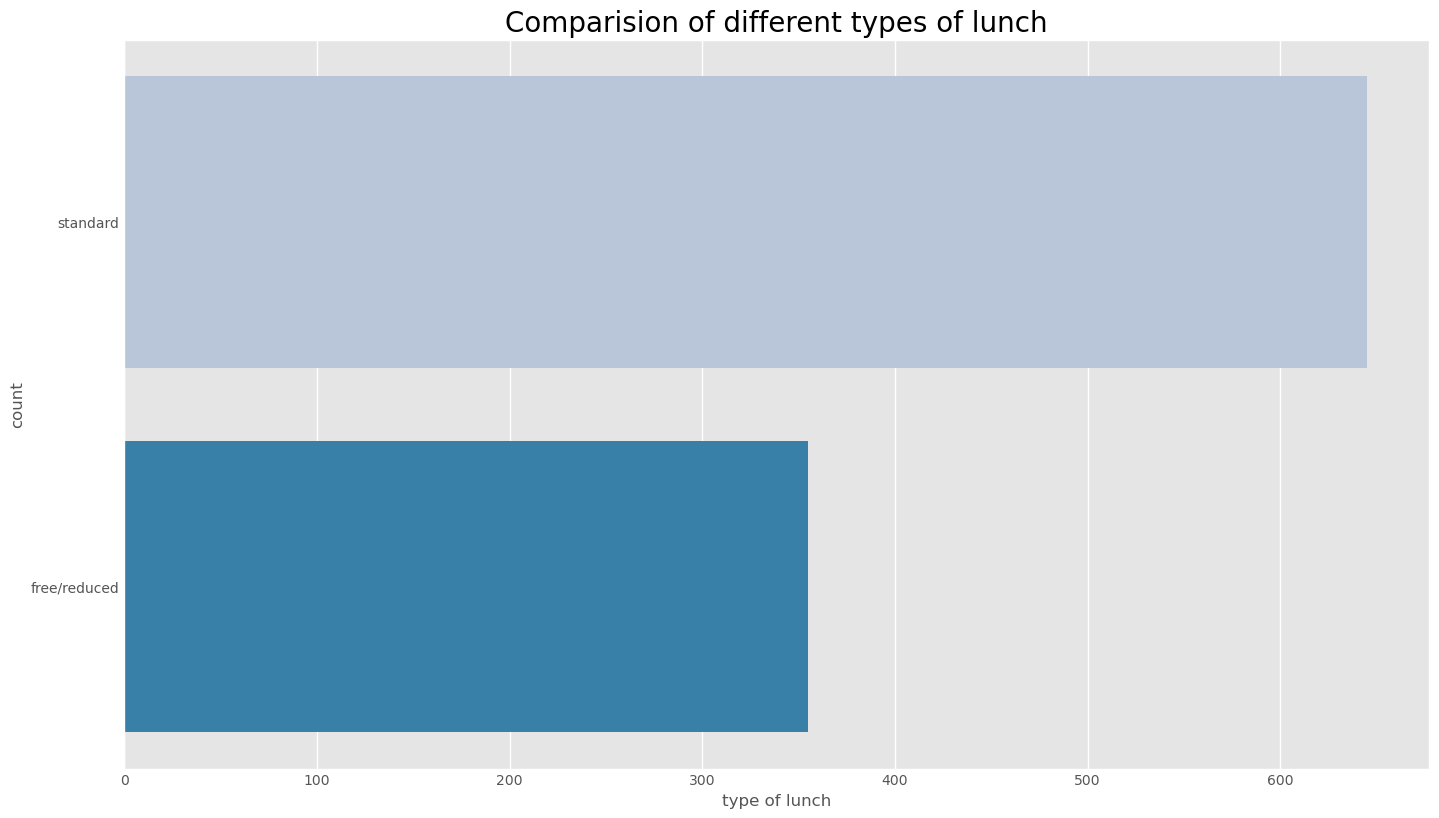

In [30]:
# UNIVARIATE ANALYSIS (Which type of lunch is most common among students?)

plt.rcParams['figure.figsize']= (15,9)
plt.style.use('ggplot')
sns.countplot(df['lunch'], palette='PuBu')
plt.title('Comparision of different types of lunch', fontweight=30, fontsize=20)
plt.xlabel('type of lunch')
plt.ylabel('count')
plt.show()

- Student being served Standard lunch is more than free lunch.

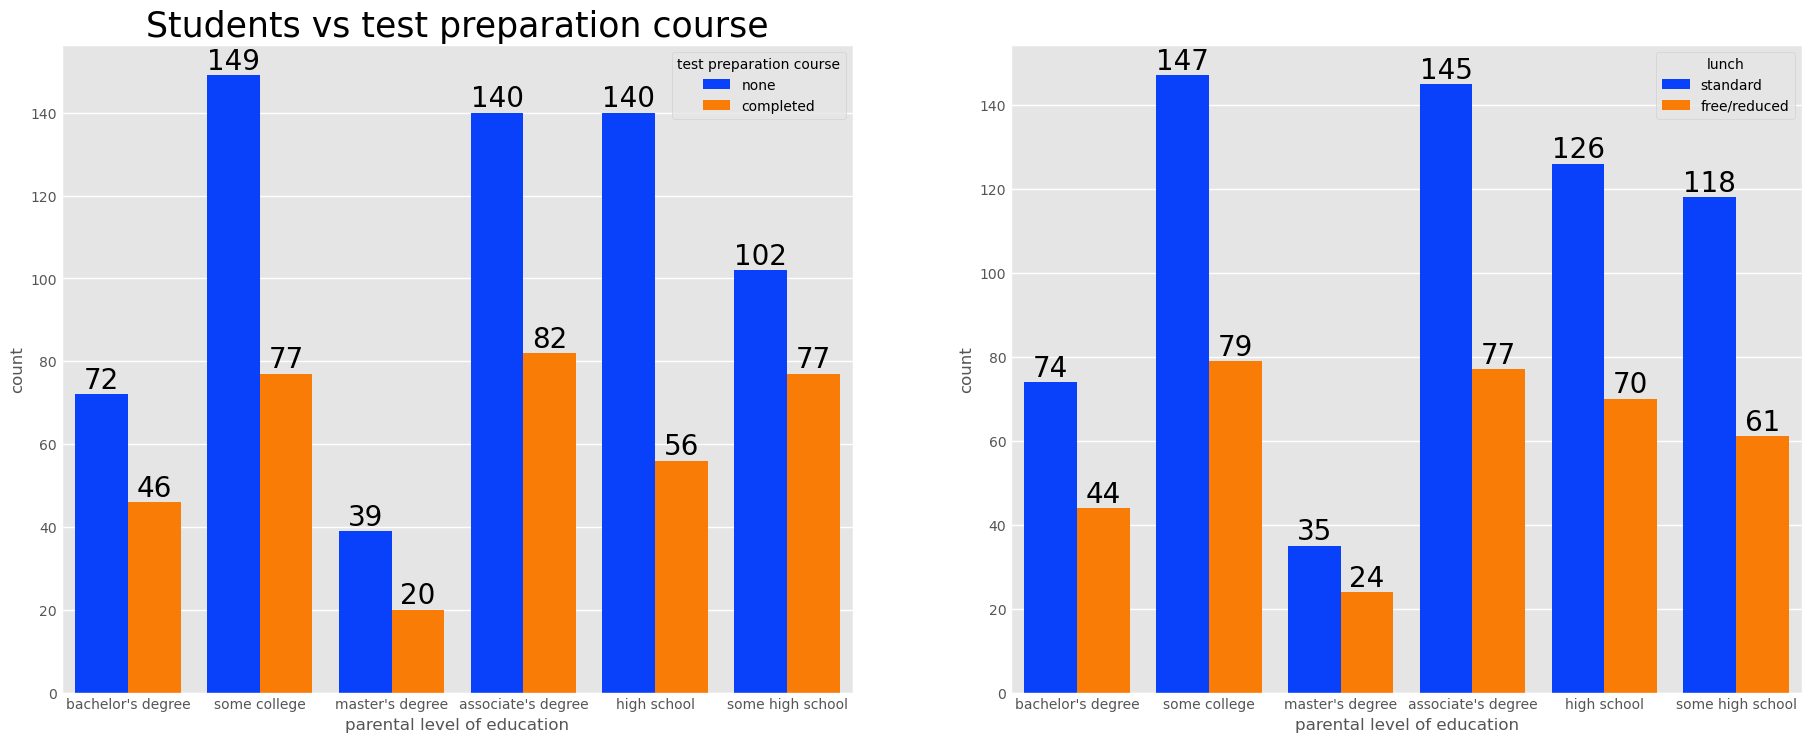

In [31]:
# BIVARIATE ANALYSIS (Is lunch type intake has any impact on student's performance?)

f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'], data=df, palette='bright', hue='test preparation course', saturation=0.95, ax=ax[0])
ax[0].set_title('Students vs test preparation course', color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

sns.countplot(x=df['parental level of education'], data=df, palette='bright', hue='lunch', saturation=0.95, ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, color='black',size=20)


- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

<Axes: xlabel='lunch', ylabel='writing score'>

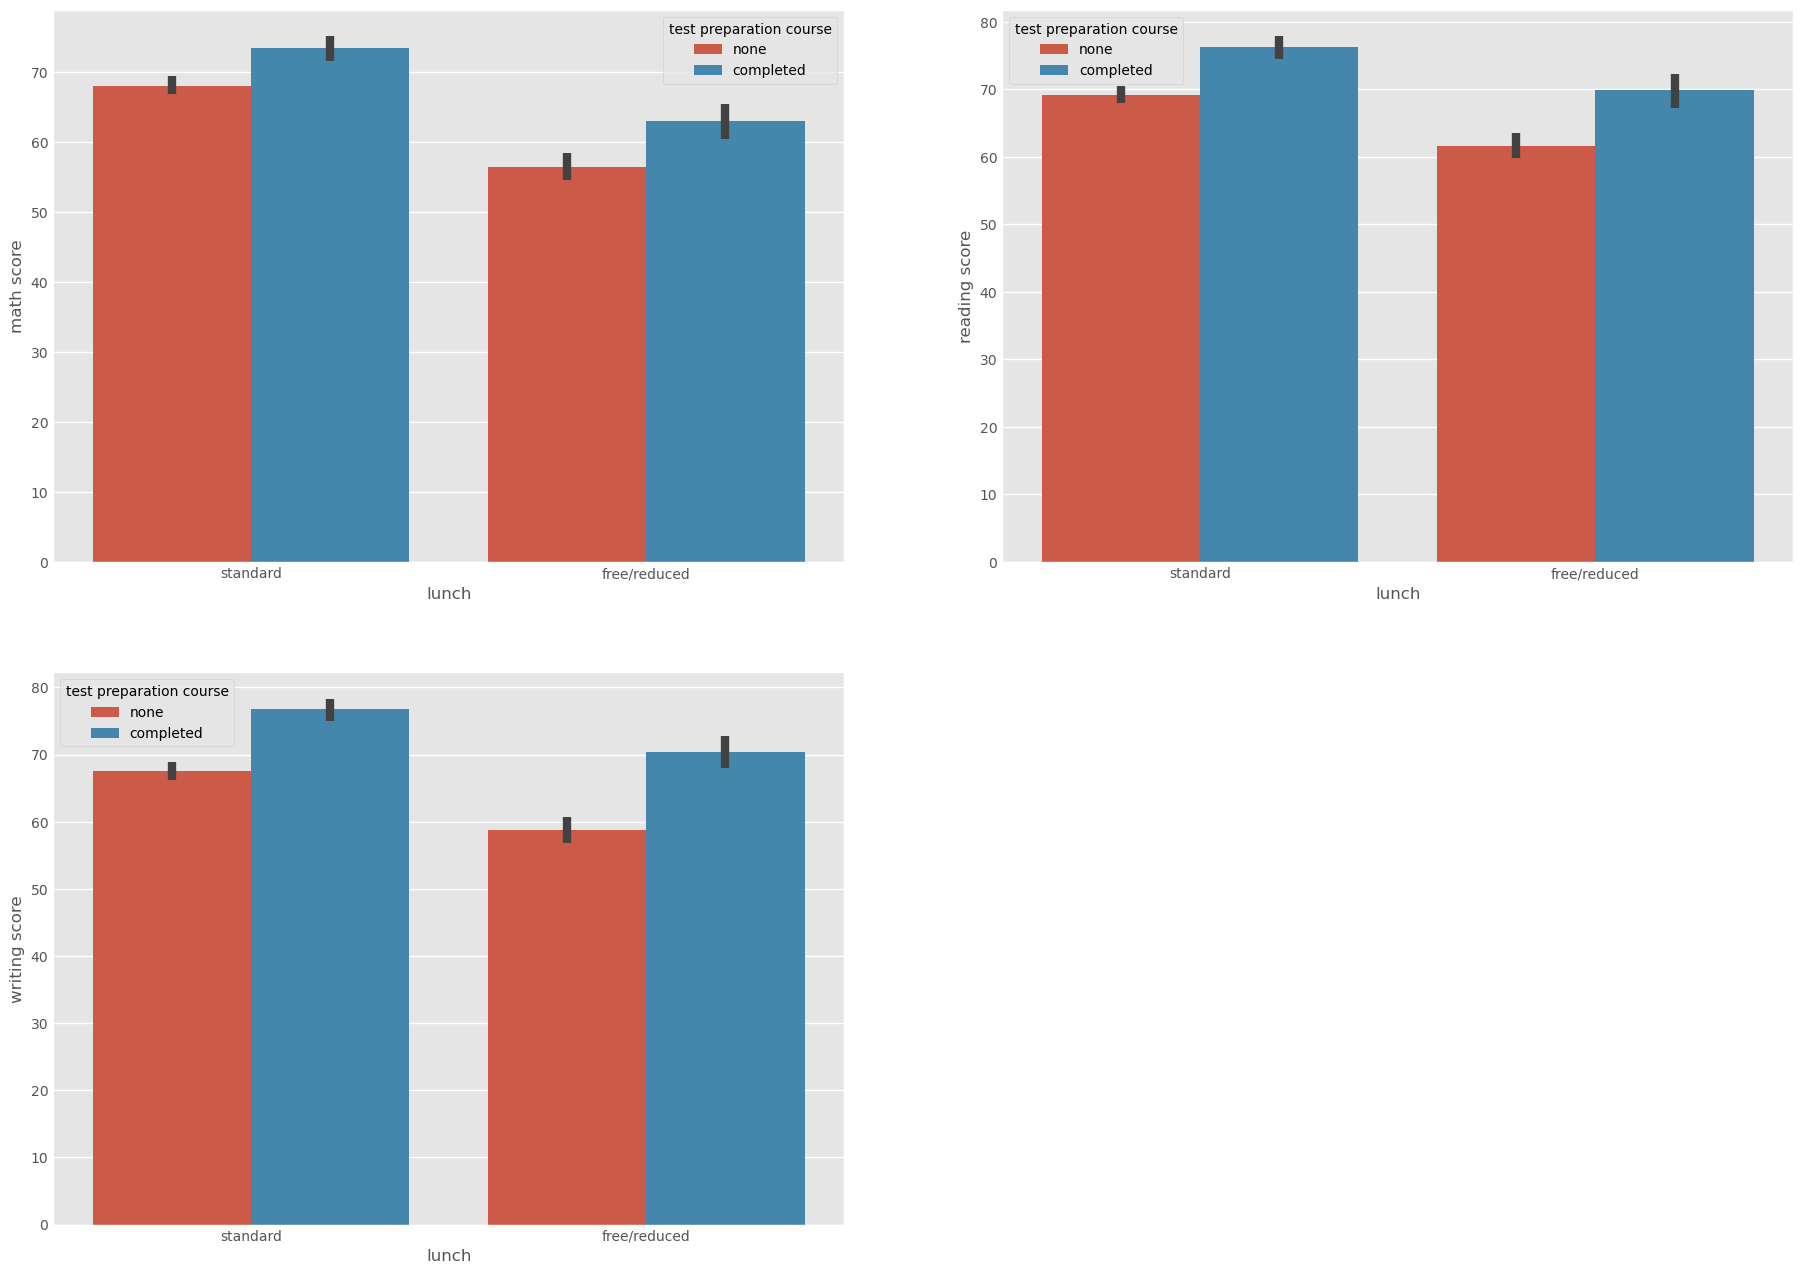

In [32]:
# BIVARIATE ANALYSIS (Is test preparation course has any impact on student's performance?)
plt.figure(figsize=(20,15))
plt.subplot(2,2,1)
sns.barplot(x=df['lunch'],y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot(x=df['lunch'],y=df['reading score'],hue=df['test preparation course'])
plt.subplot(223)
sns.barplot(x=df['lunch'],y=df['writing score'],hue=df['test preparation course'])

- students who have completed the test preparation course have scores higher in all three categories than those who haven't taken the course

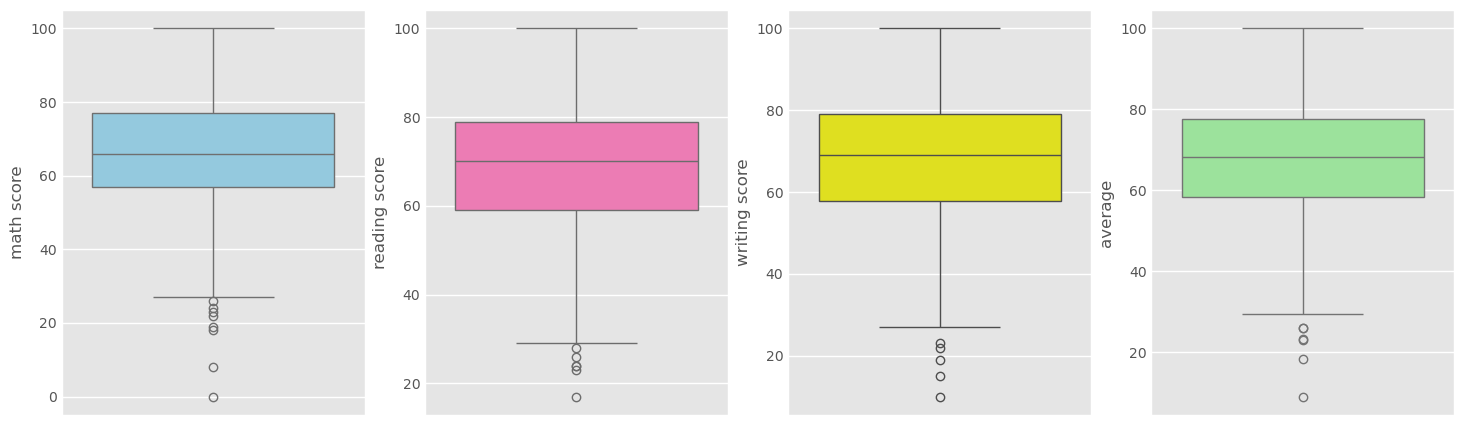

In [33]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

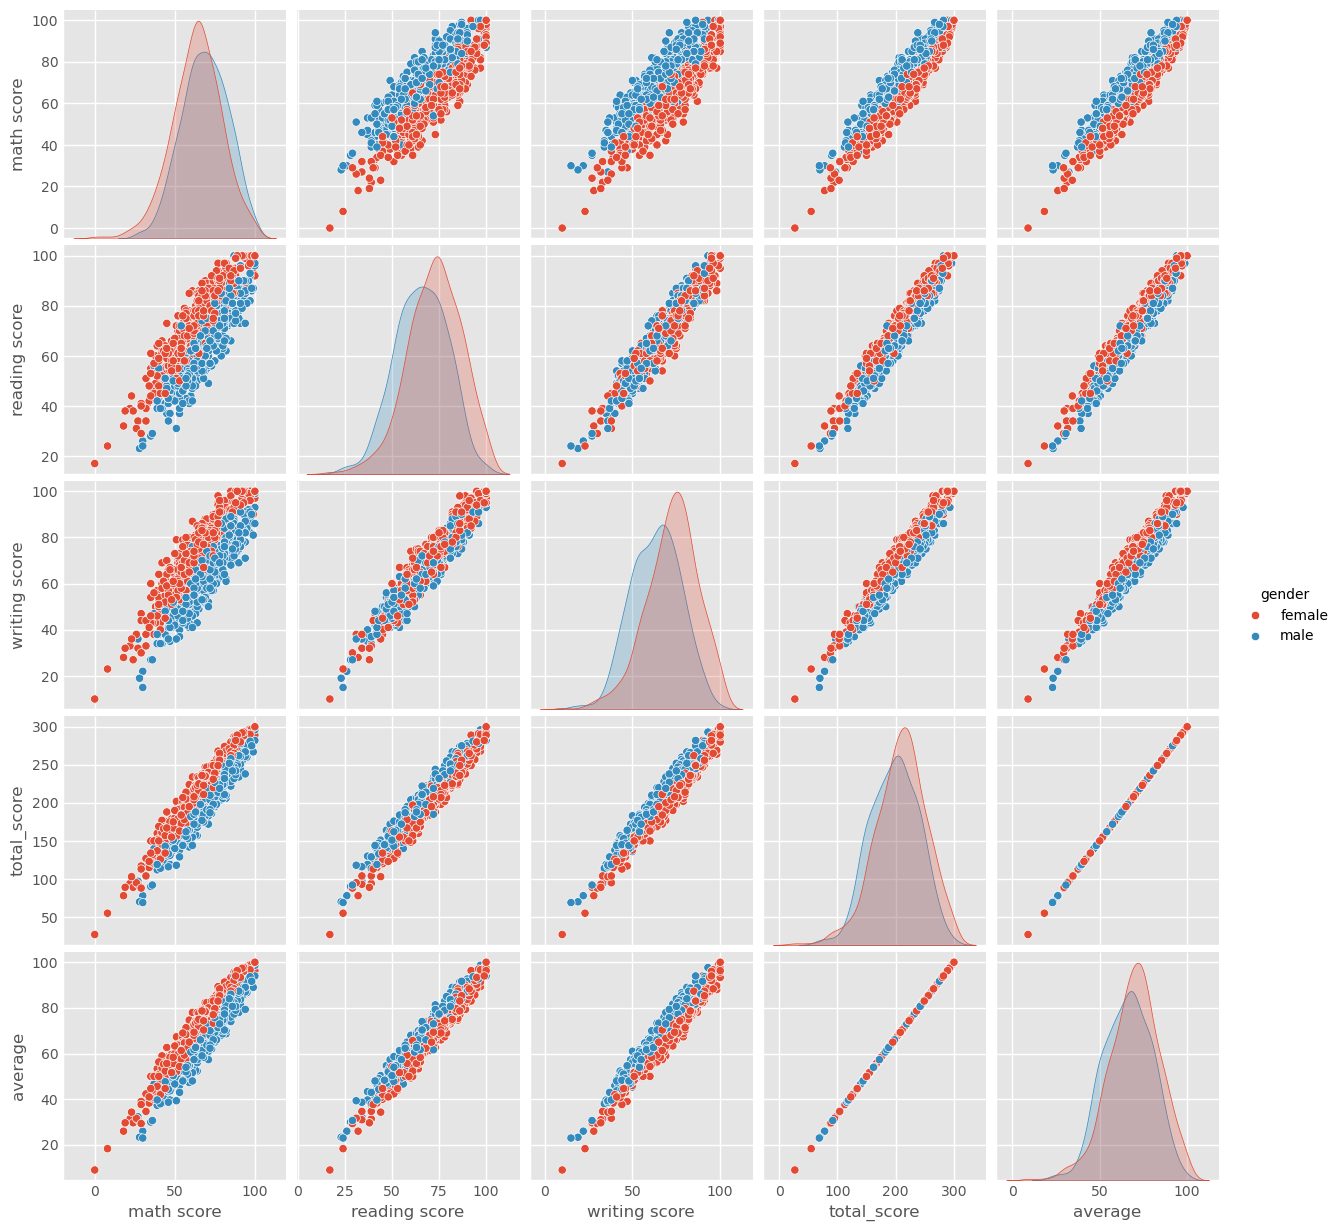

In [34]:
# MULTIVARIATE ANALYSIS USING PAIRPLOT
sns.pairplot(df,hue='gender') # sns.pairplot(data,hue=None,vars=None,x_vars=None,y_vars=None,kind='scatter',diag_kind='auto',palette=None,corner=False,...)
plt.show()

- from the above plot it is clear that all the scores increase linearly with each other.

#### Student's performance is related with lunch,race,parental level education
#### Females lead in pass percentage and also are top-scorers
#### Student's Performance is not much related with test preparation course
#### Finishing preparation course is benefitial.